In [1]:
import pickle
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.functional as F
from tqdm import tqdm

In [2]:
with open("data", "rb") as f:
    data = pickle.load(f)

In [3]:
bad = data.get("bad").copy()
good = data.get("good").copy()

In [4]:
index_chunks_b = np.split(np.arange(len(bad)),
                        # identified zeros
                        np.where(bad.index == 0)[0][1:])
index_chunks_g = np.split(np.arange(len(good)),
                        # identified zeros
                        np.where(good.index == 0)[0][1:])

In [5]:
def do(idx_bad, idx_good, extract_features,max_len=9999):
    M = []
    for chunk in idx_bad:
        df = bad.iloc[chunk][['MS2.mz', 'MS2.intensity']].copy()
        if len(df) > max_len:
            continue
        observation = {"X" : df.to_numpy(), "Y" : np.zeros((1,1),dtype=np.int64)}
        observation["X"] = torch.from_numpy(observation["X"]).unsqueeze(0)
        observation["Y"] = torch.from_numpy(observation["Y"])                                    
        M.append(observation)
    for chunk in idx_good:
        df = good.iloc[chunk][['MS2.mz', 'MS2.intensity']].copy()
        if len(df) > max_len:
            continue
        observation = {"X" : df.to_numpy(), "Y" : np.ones((1,1),dtype=np.int64)}
        observation["X"] = torch.from_numpy(observation["X"]).unsqueeze(0)
        observation["Y"] = torch.from_numpy(observation["Y"])
        M.append(observation)
    if extract_features:
        np.random.shuffle(M)
        data_X = []
        for i in range(len(M)):
            centroid = M[i]["X"].mean(axis=1)
            dists = (((M[i]["X"][0] - centroid)**2).sum(1).sqrt())
            minimum = dists.min()
            maximum = dists.max()
            mean = dists.mean()
            std = dists.std()
            q50 = dists.quantile(.5)
            q25 = dists.quantile(.25)
            obs = torch.Tensor([minimum, maximum, mean, std, q50, q25]).unsqueeze(0)
            data_X.append(obs)
        data_X = torch.cat(data_X).to(DEVICE)
        data_Y = torch.Tensor([M[i]["Y"] for i in range(len(M))]).unsqueeze(-1).to(DEVICE)
        return data_X, data_Y
    else:
        return M
        

In [6]:
train = do(index_chunks_b[:211], index_chunks_g[:211], False, 100)
val = do(index_chunks_b[211:261], index_chunks_g[211:], False, 100)

In [7]:
DEVICE="cuda:0"

In [8]:
def get_n_params(model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn
    return pp

class Attention(nn.Module):
    def __init__(self, emb, heads):
        super().__init__()

        assert emb % heads == 0, f'Embedding dimension ({emb}) should be divisible by nr. of heads ({heads})'

        self.emb = emb
        self.heads = heads

        self.W_k    = nn.Linear(emb, emb, bias=False)
        self.W_q = nn.Linear(emb, emb, bias=False)
        self.W_v  = nn.Linear(emb, emb, bias=False)
        self.W_u = nn.Linear(emb, emb)

    def forward(self, X):

        b, t, e = X.size()
        h = self.heads
        assert e == self.emb, f'Input embedding dim ({e}) should match layer embedding dim ({self.emb})'
        # chunksize of e, i.e. head dim
        s = e // h
        # query, key, value model
        K = self.W_k(X)
        Q = self.W_q(X)
        V = self.W_v(X)
        # split
        K = K.view(b, t, h, s)
        Q = Q.view(b, t, h, s)
        V = V.view(b, t, h, s)
        # prepare for dot product and scale (pbloem)
        K = K.transpose(1,2).contiguous().view(b * h, t, s) / (e ** (1/4))
        Q = Q.transpose(1,2).contiguous().view(b * h, t, s) / (e ** (1/4))
        V = V.transpose(1,2).contiguous().view(b * h, t, s) / (e ** (1/4))

        W = Q@K.transpose(1,2)
        W = torch.softmax(W, dim=2)

        assert W.size() == (b*h, t, t)

        Y = W@V
        Y = Y.view(b, h, t, s)

        # re-arange and unify heads 
        Y = Y.transpose(1, 2).contiguous().view(b, t, s * h)
        Y = self.W_u(Y)
        return Y

In [9]:
class Transformer(nn.Module):

    def __init__(self, emb=2048, heads=32, seq_length=16,dropout=0.25,ff_hidden_mult=2,device="cuda:0"):
        super().__init__()
        self.attention = Attention(emb, heads=heads)
        self.norm1 = nn.LayerNorm(emb)
        self.norm2 = nn.LayerNorm(emb)
        self.ff = nn.Sequential(
            nn.Linear(emb, ff_hidden_mult * emb),
            nn.ReLU(),
            nn.Linear(ff_hidden_mult * emb, emb)
        )
        self.do = nn.Dropout(dropout)
        self.cuda() if device == "cuda:0" else None

    def forward(self, x):

        attended = self.attention(x)
        x = self.norm1(attended + x)
        x = self.do(x)
        fedforward = self.ff(x)
        x = self.norm2(fedforward + x)
        x = self.do(x)
        #

        return x

In [10]:
class SvetaFormer(nn.Module):
    def __init__(self,N_BLOCKS,
                EMB_DIM, N_OUT,
                 HEADS,
                 T, DROPOUT, HIDDEN_MULT, DEVICE):
        super().__init__()
        self.transformer_blocks = [Transformer(EMB_DIM,
                                                  HEADS,
                                                  T,
                                                  DROPOUT,
                                                  HIDDEN_MULT,
                                                  DEVICE) for _ in range(N_BLOCKS)]
        self.transformer_blocks = nn.Sequential(*self.transformer_blocks)
        self.head =  nn.Linear(EMB_DIM, N_OUT).to(DEVICE)

    def forward(self, X):
        X = self.transformer_blocks(X)
        X = X.mean(axis=1)
        Y = self.head(X)
        #Y = torch.sigmoid(Y)
        return Y

In [11]:
class SvetaNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.do = nn.Dropout(0.5)
        self.bn1 = nn.BatchNorm1d(200)
        self.bn2 = nn.BatchNorm1d(100)
        self.fc1 = nn.Linear(200, 100)
        self.fc2 = nn.Linear(100, 1)
        
    def total_params(self, requires_grad=True):
        pp=0
        for p in list(self.parameters()):
            if not p.requires_grad:
                continue
            nn=1
            for s in list(p.size()):
                nn = nn*s
            pp += nn
        return pp
    
    def forward(self, x):
        x = self.bn1(x)
        x = self.fc1(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.do(x)
        
        
        x = self.fc2(x)
        return x

In [12]:

    
class SvetaResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.do = nn.Dropout(0.66)
        self.bn = nn.BatchNorm1d(200)
        self.fc1 = nn.Linear(200, 200)
        self.fc2 = nn.Linear(200, 200)
        self.fc3 = nn.Linear(200, 200)
        self.fc4 = nn.Linear(200, 200)
        self.fc5 = nn.Linear(200, 1)
        
    def total_params(self, requires_grad=True):
        pp=0
        for p in list(self.parameters()):
            if not p.requires_grad:
                continue
            nn=1
            for s in list(p.size()):
                nn = nn*s
            pp += nn
        return pp
    
    def forward(self, x):
        x1 = self.bn(x)
        x1 = self.fc1(x1)
        x2 = F.relu(x1 + x)
        
        x2 = self.do(x2)
        x2 = self.fc2(x2)
        x2 = self.bn(x2)
        x3 = F.relu(x2 + x1)

        x3 = self.do(x3)
        x3 = self.fc3(x3)
        x3 = self.bn(x3)
        x4 = F.relu(x3 + x2)
        
        x4 = self.do(x4)
        x4 = self.fc4(x4)
        x4 = self.bn(x4)
        x5 = F.relu(x4 + x3)
        
        y = self.fc5(x5)
        
        return y
    

In [13]:
from IPython.display import clear_output

$$
        \ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad
        l_n = - w_n \left[ y_n \cdot \log x_n + (1 - y_n) \cdot \log (1 - x_n) \right], \ell(x, y) = \begin{cases}
            \operatorname{mean}(L), & \text{if reduction} = \text{`mean';}\\
            \operatorname{sum}(L),  & \text{if reduction} = \text{`sum'.}
        \end{cases}
$$

In [14]:
import torch.nn.functional as F

In [15]:
max_= 0
for i in range(len(train)):
    if train[i]["X"].shape[1] > max_:
        max_ = train[i]["X"].shape[1]
        print(max_)
for i in range(len(val)):
    if val[i]["X"].shape[1] > max_:
        max_ = val[i]["X"].shape[1]
        print(max_)
        
for i in range(len(train)):
    l = train[i]["X"].shape[1]
    if l < max_:
        train[i]["X"] = F.pad(train[i]["X"], (0,0,0,max_ - l), "constant", 0)
for i in range(len(val)):
    l = val[i]["X"].shape[1]
    if l < max_:
        val[i]["X"] = F.pad(val[i]["X"], (0,0,0,max_ - l), "constant", 0)
        


23
34
47
76
80
85
90
97
99
100


In [16]:
train_x = torch.cat([train[i]["X"] for i in range(len(train))])
train_y = torch.cat([train[i]["Y"] for i in range(len(train))])

val_x = torch.cat([val[i]["X"] for i in range(len(val))]).to(DEVICE)
val_y = torch.cat([val[i]["Y"] for i in range(len(val))]).to(DEVICE)

idx = torch.randperm(train_x.shape[0])
train_x = train_x[idx].to(DEVICE)
train_y = train_y[idx].to(DEVICE)

In [23]:
net = SvetaNet().to(DEVICE)
train_x = train_x.view(train_x.shape[0], max_*2)

val_x = val_x.view(val_x.shape[0], max_*2)

In [24]:
get_n_params(net)

20801

In [25]:
optimizer = torch.optim.Adam(net.parameters(), lr=0.00002)
bce = torch.nn.BCEWithLogitsLoss()

In [26]:
batch_size = 12
n_epochs = 1000

In [27]:
epochs = dict()
epochs_acc = dict()
epochs_val = dict()
epochs_acc_val = dict()
for epoch in tqdm(range(n_epochs)):
    epochs[epoch] = list()
    epochs_acc[epoch] = list()
    epochs_val[epoch] = list()
    epochs_acc_val[epoch] = list()
    idx = torch.randperm(train_x.shape[0])
    train_x = train_x[idx]
    train_y = train_y[idx]
    for i in range(0, len(train_x), batch_size):
        optimizer.zero_grad()
        X = train_x[i:i+batch_size].float()
        y = train_y[i:i+batch_size].float()
        yhat = net(X)
        loss = bce(yhat,y)
        loss.backward()
        optimizer.step()
        preds = torch.where(yhat.detach().sigmoid() > .5, 1., 0.)
        acc = torch.where(preds == y.detach(), 1., 0.).mean()
        epochs[epoch].append(loss.item())
        epochs_acc[epoch].append(acc.item())
    for i in range(0, len(val_x), batch_size):
        with torch.no_grad():
            X = val_x[i:i+batch_size].float()
            y = val_y[i:i+batch_size].float()
            yhat = net(X)
            loss = bce(yhat,y)
            preds = torch.where(yhat.detach().sigmoid() > .5, 1., 0.)
            acc = torch.where(preds == y.detach(), 1., 0.).mean()
            epochs_val[epoch].append(loss.item())
            epochs_acc_val[epoch].append(acc.item())
            #print(list(f.modules())[1].weight.grad.sum())

100%|███████████████████████████████████████| 1000/1000 [00:48<00:00, 20.52it/s]


In [280]:
import matplotlib.pyplot as plt

<AxesSubplot:>

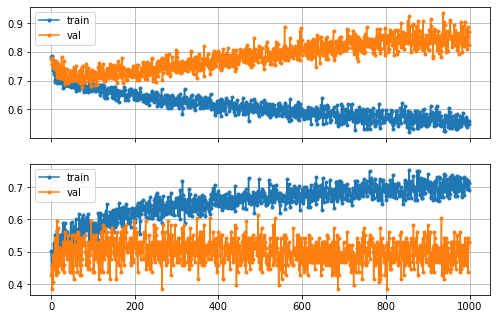

In [281]:
res_mean = pd.DataFrame({"train" : [pd.Series(epochs[_]).mean() for _ in epochs],
                         "val"   : [pd.Series(epochs_val[_]).mean() for _ in epochs_val]})
acc = pd.DataFrame({"train" : [pd.Series(epochs_acc[_]).mean() for _ in epochs],
                         "val"   : [pd.Series(epochs_acc_val[_]).mean() for _ in epochs_val]})
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8.24,5.3))
res_mean.plot(grid=True, style=".-", ax=axes[0])
acc.plot(grid=True, style=".-", ax=axes[1])